In [30]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)
print(f"Working from: {project_root}")

Working from: c:\Users\ChandrG\ML-Project-Titanic


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from src import config

print("✅ All imports successful!")
print(f"Training data path: {config.TRAIN_DATA_PATH}")

✅ All imports successful!
Training data path: c:\Users\ChandrG\ML-Project-Titanic\src\..\data\raw\train.csv


In [32]:
df_train = pd.read_csv(config.TRAIN_DATA_PATH)
display(df_train.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Section 1: Basic Exploration

In [33]:
print(f"Dataset Shape: {df_train.shape} (rows x columns)")
print(f"Memory Usage: {df_train.memory_usage(deep=True).sum() / 1024:.2f} KB")

Dataset Shape: (891, 12) (rows x columns)
Memory Usage: 285.61 KB


In [34]:
print("\n=== COLUMN INFORMATION ===")
df_train.info()


=== COLUMN INFORMATION ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [35]:
print("\n=== DATA TYPES SUMMARY ===")
dtype_count = df_train.dtypes.value_counts()
print(dtype_count)


=== DATA TYPES SUMMARY ===
int64      5
str        5
float64    2
Name: count, dtype: int64


In [36]:
print("\n=== MISSING VALUES ANALYSIS ===")
missing_values = df_train.isnull().sum()
missing_percent = (missing_values / len(df_train)) * 100
missing_df = pd.DataFrame({"Missing Count" : missing_values, "Missing %": missing_percent.round(2) })
print(missing_df[missing_df["Missing Count"] > 0])


=== MISSING VALUES ANALYSIS ===
          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22


In [37]:
print("\n=== DESCRIPTIVE STATISTICS FOR NUMERIC COLUMNS ===")
numeric_cols = df_train.select_dtypes(include = [np.number]).columns
print(df_train[numeric_cols].describe())


=== DESCRIPTIVE STATISTICS FOR NUMERIC COLUMNS ===
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [38]:
print("\n=== DESCRIPTIVE STATISTICS FOR CATEGORICAL COLUMNS ===")
cat_cols = df_train.select_dtypes(include = ["object"]).columns
for i in cat_cols:
    print(f"\n{i}:")
    print(f"  Unique Values: {df_train[i].nunique()}")
    print(f"  Most Common: {df_train[i].mode()[0]} (Count: {df_train[i].value_counts().iloc[0]})")
    print(f"  \nValue counts:{df_train[i].value_counts().head()}")


=== DESCRIPTIVE STATISTICS FOR CATEGORICAL COLUMNS ===

Name:
  Unique Values: 891
  Most Common: Abbing, Mr. Anthony (Count: 1)
  
Value counts:Name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
Name: count, dtype: int64

Sex:
  Unique Values: 2
  Most Common: male (Count: 577)
  
Value counts:Sex
male      577
female    314
Name: count, dtype: int64

Ticket:
  Unique Values: 681
  Most Common: 1601 (Count: 7)
  
Value counts:Ticket
347082      7
1601        7
CA. 2343    7
3101295     6
CA 2144     6
Name: count, dtype: int64

Cabin:
  Unique Values: 147
  Most Common: B96 B98 (Count: 4)
  
Value counts:Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
Name: count, dtype: int64

Embarked:
  Unique Values: 3


C:\Users\ChandrG\AppData\Local\Temp\1\ipykernel_28380\1774146113.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_train.select_dtypes(include = ["object"]).columns


In [39]:
print("\n=== BASIC INSIGHTS ===")
print(f"Survival Rate: {df_train['Survived'].mean() * 100:.2f}%")
print(f"Most common passenger class: {df_train['Pclass'].mode()[0]}")
print(f"Average age: {df_train['Age'].mean():.1f} years")
print(f"Gender distribution: {df_train['Sex'].value_counts().to_dict()}")


=== BASIC INSIGHTS ===
Survival Rate: 38.38%
Most common passenger class: 3
Average age: 29.7 years
Gender distribution: {'male': 577, 'female': 314}


Section 2: Data Visualization & Analysis
Objetives:
    What do individual features look like?
    Which features correlate with survival?
    What relationships exist between features?
    Which visual patterns should guide our feature engineering?

Section 2 structure
    Univariate plots
    Target-based bivariate plots
    Correlation / relationships
    Statistical insights from visuals

In [40]:
# Plotting Setup
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

C:\Users\ChandrG\AppData\Local\Temp\1\ipykernel_28380\2446623169.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x = "Survived", palette = "Set2")
C:\Users\ChandrG\AppData\Local\Temp\1\ipykernel_28380\2446623169.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='Pclass', palette='Set1')
C:\Users\ChandrG\AppData\Local\Temp\1\ipykernel_28380\2446623169.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='Sex', palette='pastel')
C:\Users\ChandrG\AppData\Local\Temp\1\ipykernel_28380\

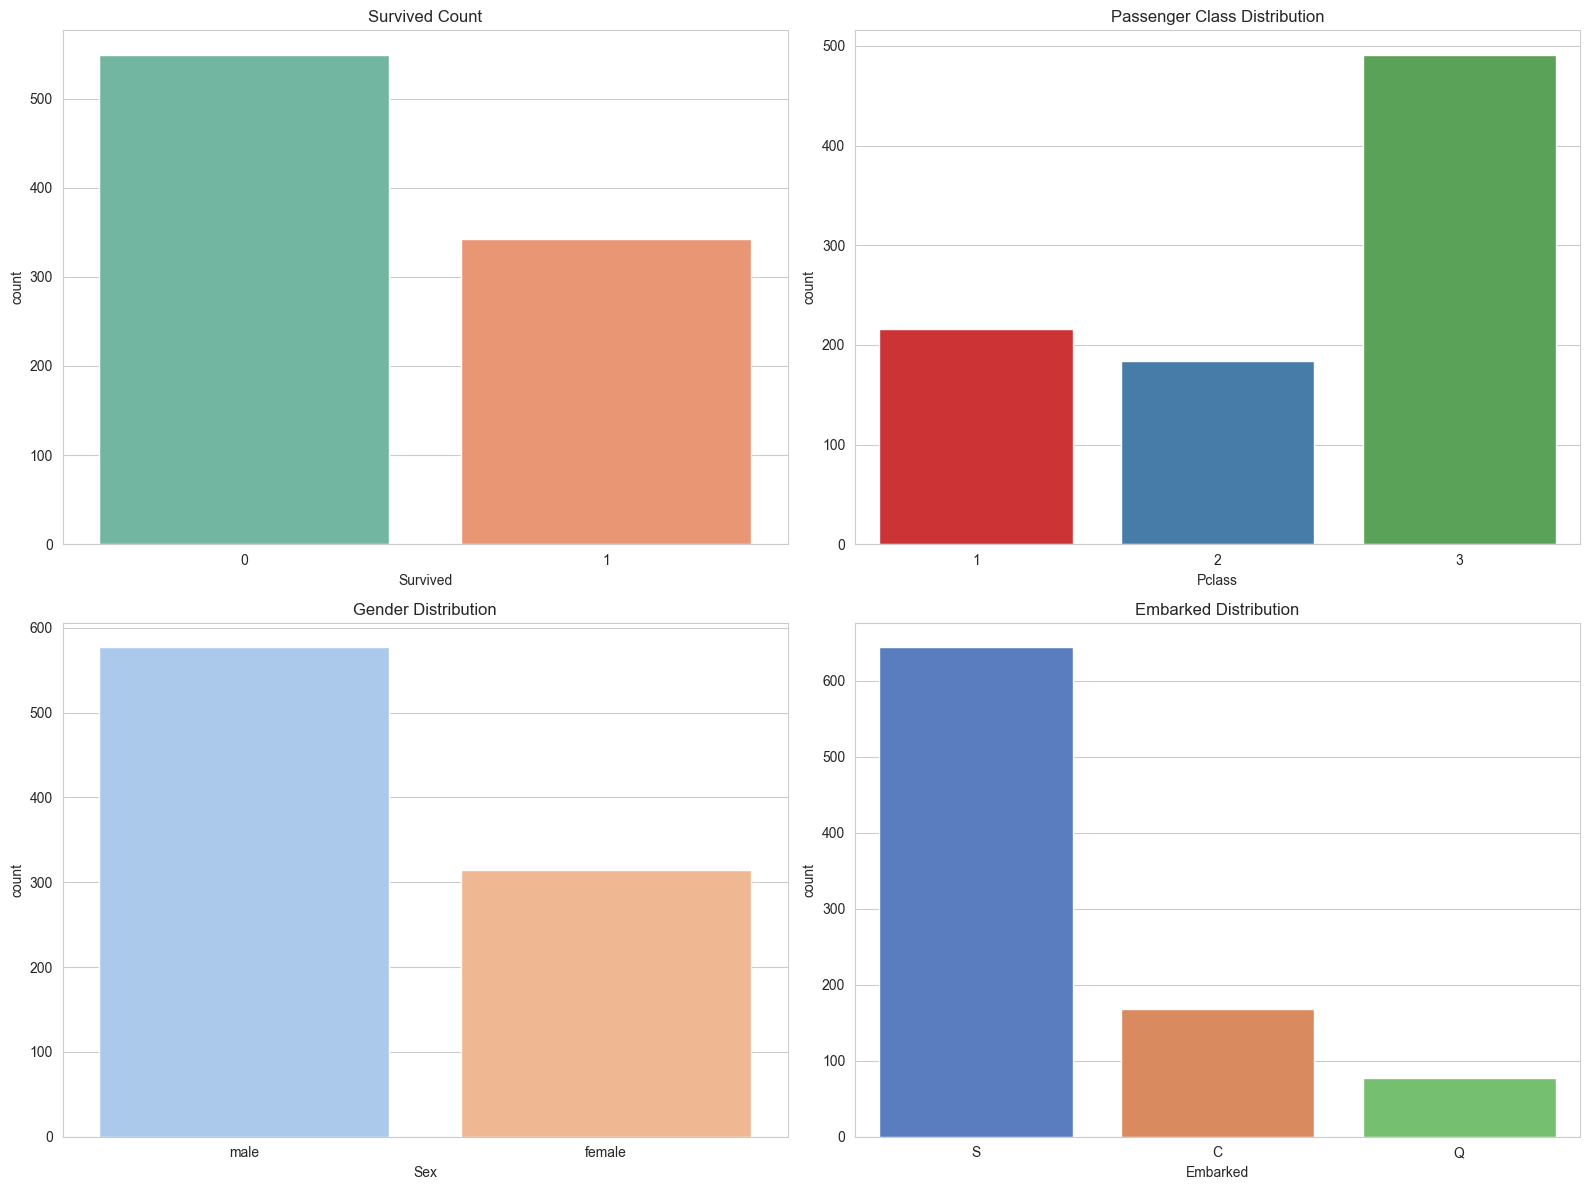

In [41]:
# Univariate distributions

plt.figure(figsize = (16,12))

plt.subplot(2,2,1)
sns.countplot(data=df_train, x = "Survived", palette = "Set2")
plt.title('Survived Count')
plt.xlabel('Survived')

plt.subplot(2, 2, 2)
sns.countplot(data=df_train, x='Pclass', palette='Set1')
plt.title('Passenger Class Distribution')
plt.xlabel('Pclass')

plt.subplot(2, 2, 3)
sns.countplot(data=df_train, x='Sex', palette='pastel')
plt.title('Gender Distribution')

plt.subplot(2, 2, 4)
sns.countplot(data=df_train, x='Embarked', palette='muted')
plt.title('Embarked Distribution')

plt.tight_layout()
plt.show()

C:\Users\ChandrG\AppData\Local\Temp\1\ipykernel_28380\3068466847.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=df_train, palette='Set3')
C:\Users\ChandrG\AppData\Local\Temp\1\ipykernel_28380\3068466847.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=df_train, palette='Set3')


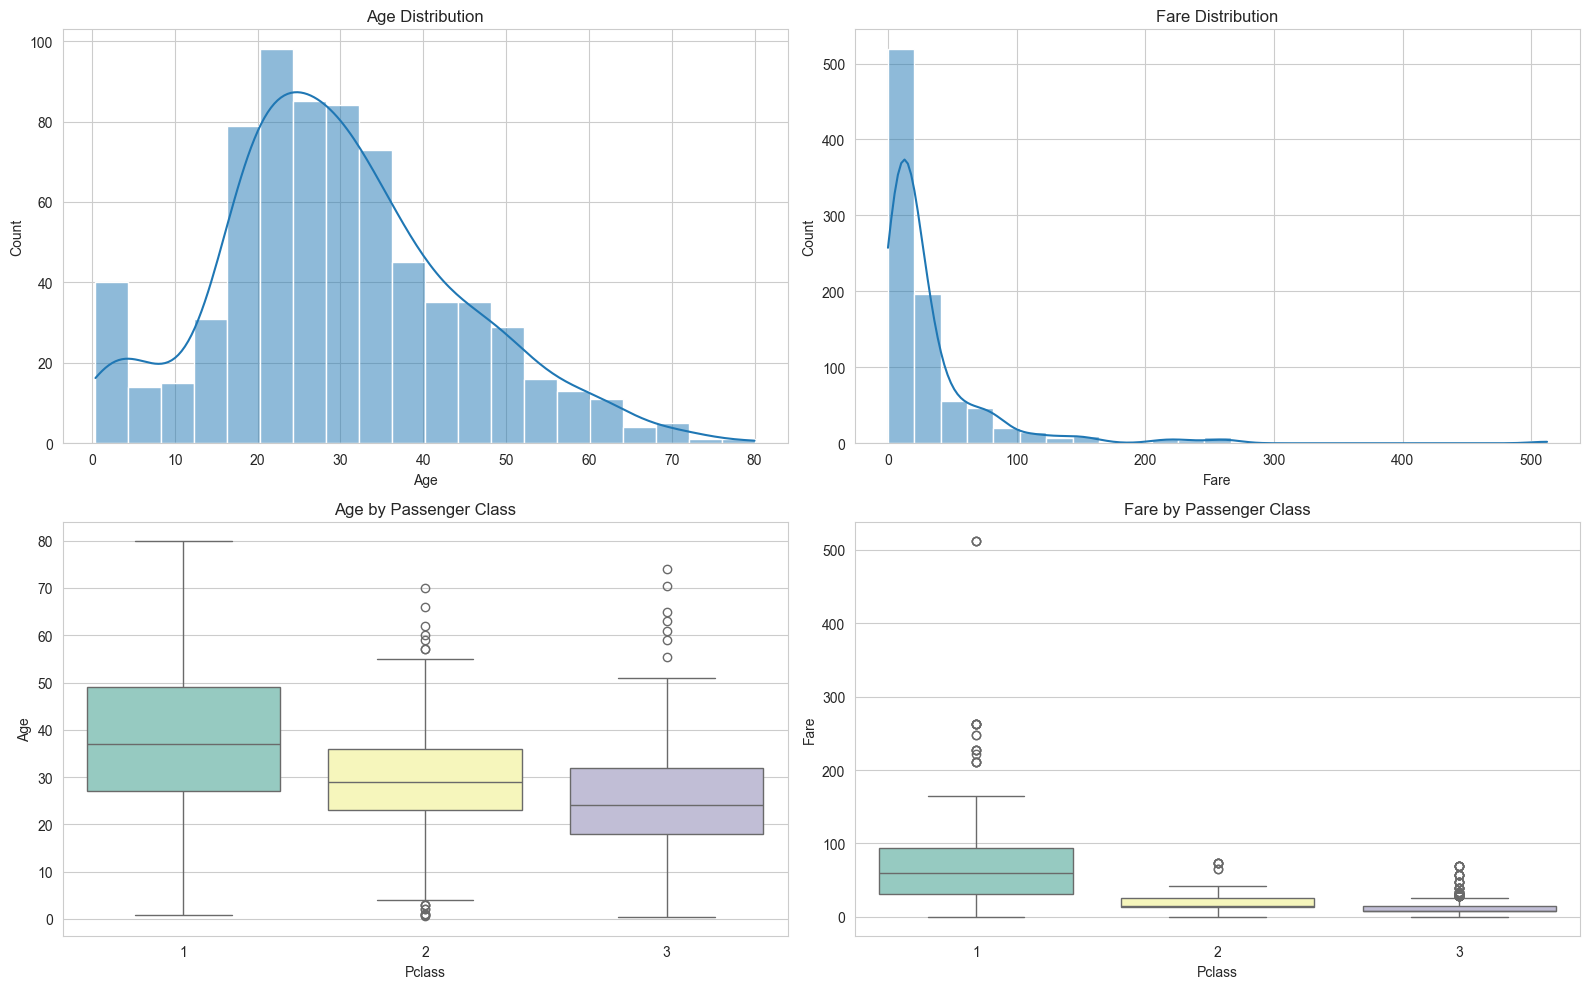

In [42]:
# Numeric feature distributions

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
sns.histplot(df_train['Age'].dropna(), bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')

plt.subplot(2, 2, 2)
sns.histplot(df_train['Fare'], bins=25, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Fare')

plt.subplot(2, 2, 3)
sns.boxplot(x='Pclass', y='Age', data=df_train, palette='Set3')
plt.title('Age by Passenger Class')

plt.subplot(2, 2, 4)
sns.boxplot(x='Pclass', y='Fare', data=df_train, palette='Set3')
plt.title('Fare by Passenger Class')

plt.tight_layout()
plt.show()

C:\Users\ChandrG\AppData\Local\Temp\1\ipykernel_28380\2956919222.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='Sex', y='Survived', palette='Set2')
C:\Users\ChandrG\AppData\Local\Temp\1\ipykernel_28380\2956919222.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='Pclass', y='Survived', palette='Set2')
C:\Users\ChandrG\AppData\Local\Temp\1\ipykernel_28380\2956919222.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='Embarked', y='Survived', palette='Set2')
C:\Users\ChandrG\AppData

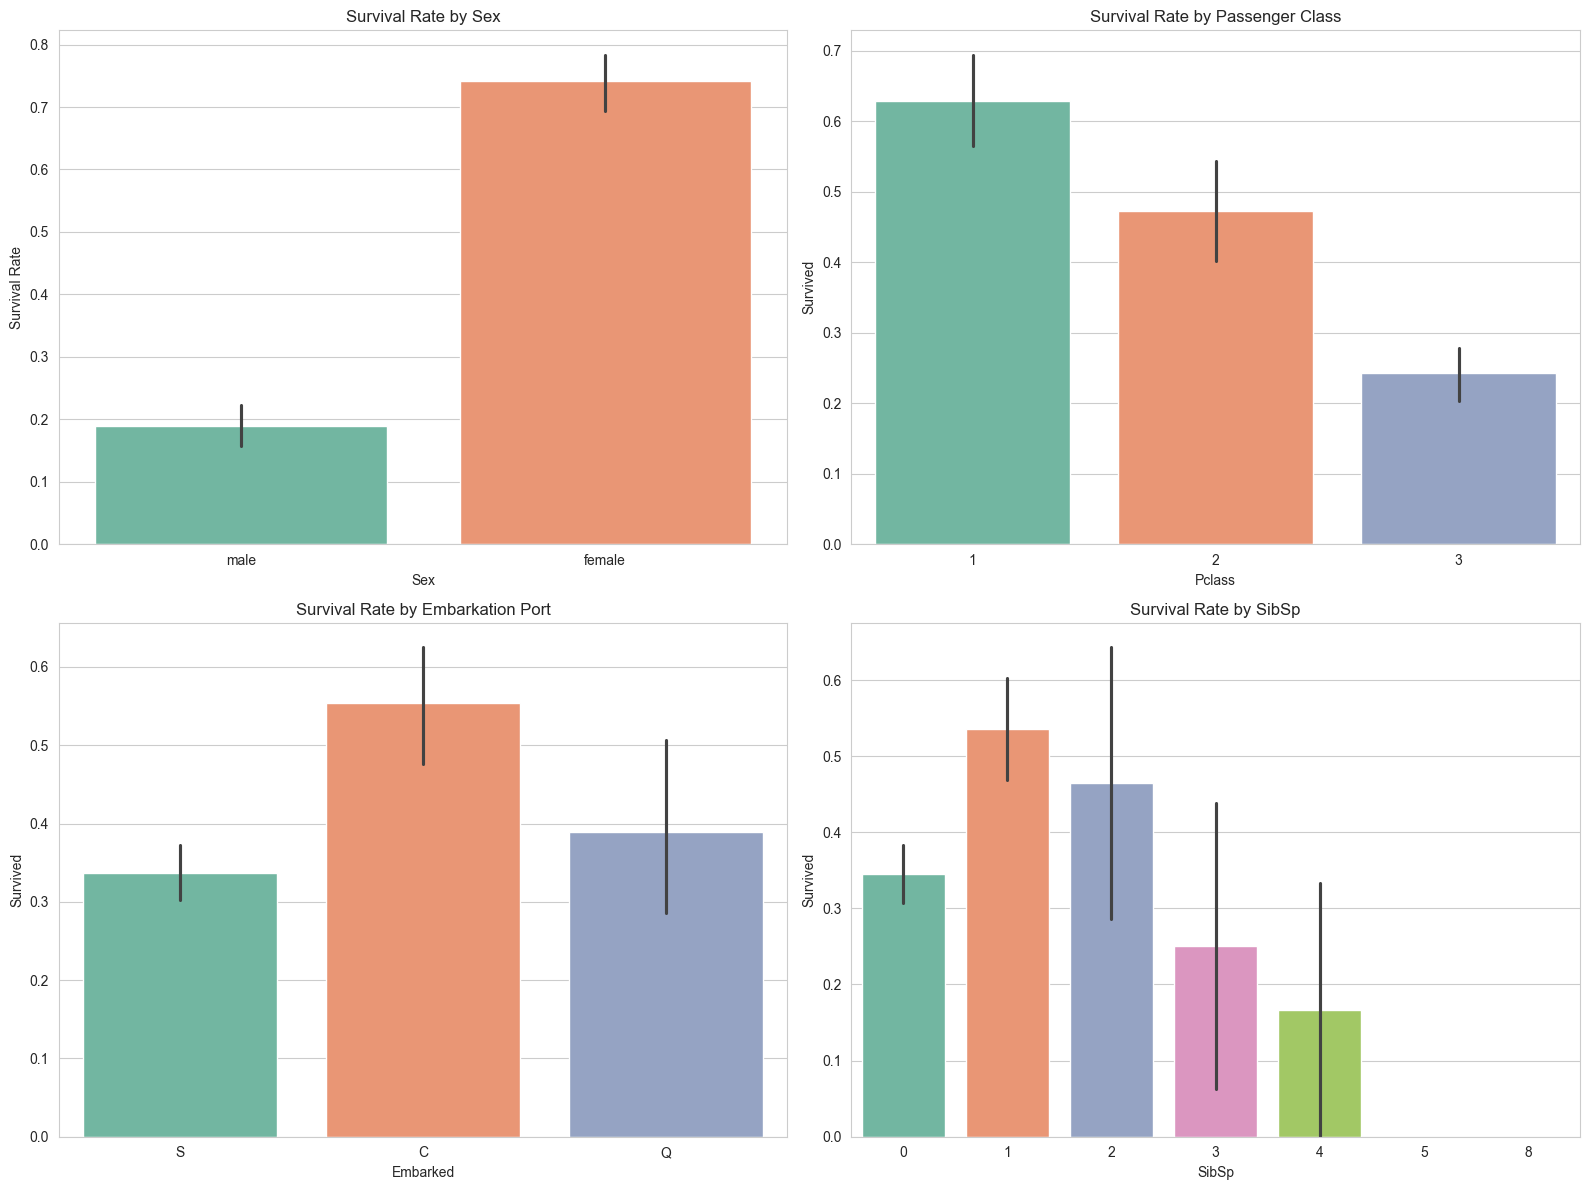

In [43]:
# Survival by category

plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.barplot(data=df_train, x='Sex', y='Survived', palette='Set2')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')

plt.subplot(2, 2, 2)
sns.barplot(data=df_train, x='Pclass', y='Survived', palette='Set2')
plt.title('Survival Rate by Passenger Class')

plt.subplot(2, 2, 3)
sns.barplot(data=df_train, x='Embarked', y='Survived', palette='Set2')
plt.title('Survival Rate by Embarkation Port')

plt.subplot(2, 2, 4)
sns.barplot(data=df_train, x='SibSp', y='Survived', palette='Set2')
plt.title('Survival Rate by SibSp')

plt.tight_layout()
plt.show()

C:\Users\ChandrG\AppData\Local\Temp\1\ipykernel_28380\441759063.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train.loc[df_train['Survived'] == 0, 'Age'].dropna(), label='Died', shade=True)
C:\Users\ChandrG\AppData\Local\Temp\1\ipykernel_28380\441759063.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train.loc[df_train['Survived'] == 1, 'Age'].dropna(), label='Survived', shade=True)


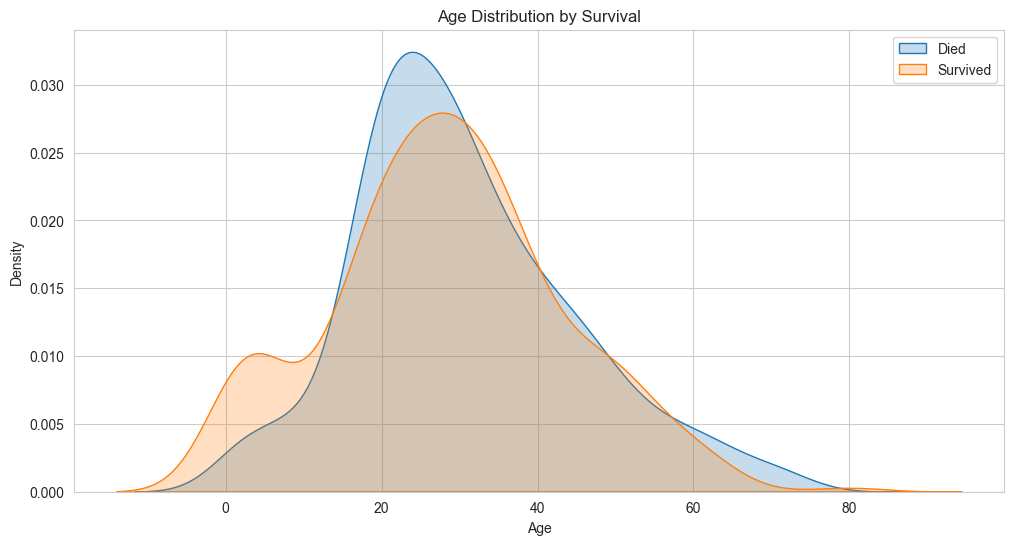

In [44]:
# Age distribution by survival
plt.figure(figsize=(12, 6))
sns.kdeplot(df_train.loc[df_train['Survived'] == 0, 'Age'].dropna(), label='Died', shade=True)
sns.kdeplot(df_train.loc[df_train['Survived'] == 1, 'Age'].dropna(), label='Survived', shade=True)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.legend()
plt.show()

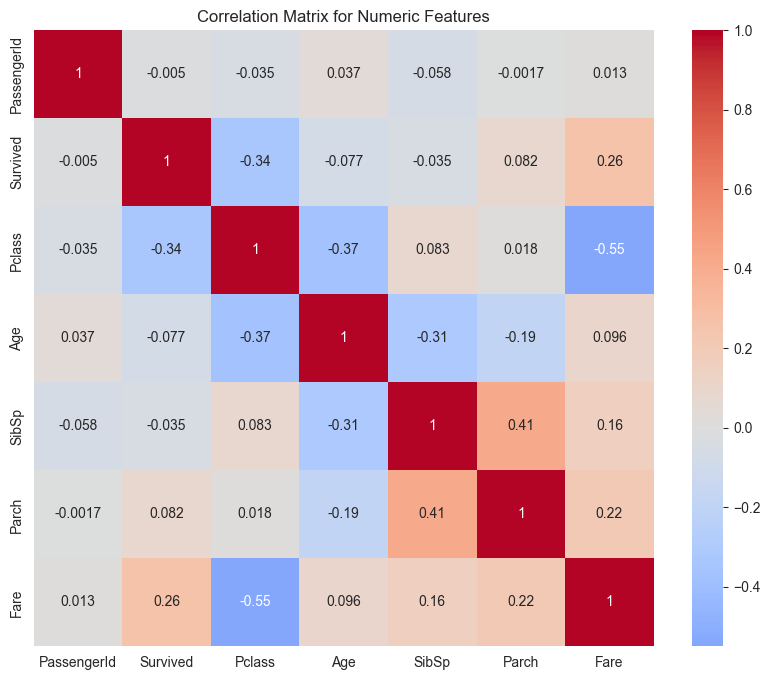

In [45]:
# Correlation heatmap

numeric_cols = df_train.select_dtypes(include=[np.number]).columns
corr_matrix = df_train[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Numeric Features')
plt.show()

## Statistical Learnings From Section 2

This section is where visual intuition should be converted into statistical thinking.

Key interpretations from the plots:

1. A survival-rate bar plot is not just a chart. Since `Survived` is binary, the average value within a group is the empirical probability of survival for that group.
2. If one category has a clearly higher bar than another, we are observing a difference in conditional probability, not proving causation.
3. Histograms and KDE plots describe the shape of a distribution. They help us see skewness, spread, concentration, and possible nonlinear effects.
4. The correlation heatmap is useful, but it only measures linear association among numeric variables. A low correlation does not mean a feature is useless.

Questions to reflect on before modeling:

- Which variables seem to carry strong signal for survival?
- Which variables may interact with each other, such as `Sex`, `Pclass`, and `Fare`?
- Which patterns seem stable enough to test in a model, and which ones might just be visual noise?
- Which transformations are deterministic feature creation, and which ones estimate values from the data and therefore can cause leakage later?

Section 3: Feature Engineering Prototype or Preprocessing Design Draft

Section 3 performs transformations on the full training dataset and then saves the result. That is completely fine for learning feature ideas, but it is not statistically safe as the final preprocessing path for model evaluation.

Concept:
When we compute quantities like the median age or mode of embarked using the full dataset, we are using information from rows that should later behave like unseen validation data.

Mathematically, if a preprocessing statistic is estimated from all observations,

θ^ = g(Dall)
then later validation is no longer independent of preprocessing.

Objectives:
- Missing value handling
- Feature engineering
- Categorical encoding
- Save processed data

In [46]:
# Missing value handling


df = df_train.copy()

print("Missing before cleaning:")
print(df.isnull().sum())

# 1. Fill Age with median
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
print("\nFilled Age missing values with median:", age_median)

# 2. Fill Embarked with mode
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
print("Filled Embarked missing values with mode:", embarked_mode)

# 3. Drop Cabin column
df.drop(columns=['Cabin'], inplace=True)
print("Dropped Cabin column due to high missing rate.")

# 4. Verify final missing values
print("\nMissing after cleaning:")
print(df.isnull().sum())

Missing before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Filled Age missing values with median: 28.0
Filled Embarked missing values with mode: S
Dropped Cabin column due to high missing rate.

Missing after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [47]:
# Feature engineering
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

# Extract Title from Name
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

title_mapping = {
    'Mr': 'Mr', 'Mrs': 'Mrs', 'Miss': 'Miss', 'Master': 'Master',
    'Don': 'Royalty', 'Rev': 'Officer', 'Dr': 'Officer',
    'Mme': 'Mrs', 'Ms': 'Mrs', 'Major': 'Officer', 'Lady': 'Royalty',
    'Sir': 'Royalty', 'Mlle': 'Miss', 'Col': 'Officer',
    'Capt': 'Officer', 'Countess': 'Royalty', 'Jonkheer': 'Royalty',
    'Dona': 'Royalty'
}
df['Title'] = df['Title'].replace(title_mapping)
df['Title'] = df['Title'].fillna('Other')

# Binning age
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teen', 'Young_Adult', 'Adult', 'Senior']
df['Age_Bin'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Binning fare into quartiles
df['Fare_Bin'] = pd.qcut(df['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very_High'])

print("\nNew features:")
print(df[['Family_Size', 'Is_Alone', 'Title', 'Age_Bin', 'Fare_Bin']].head())


New features:
   Family_Size  Is_Alone Title      Age_Bin   Fare_Bin
0            2         0    Mr  Young_Adult        Low
1            2         0   Mrs        Adult  Very_High
2            1         1  Miss  Young_Adult     Medium
3            2         0   Mrs  Young_Adult  Very_High
4            1         1    Mr  Young_Adult     Medium


In [48]:
# Drop Unnecessay columns

df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
print("\nDropped PassengerId, Name, Ticket.")
print("Remaining columns:", df.columns.tolist())


Dropped PassengerId, Name, Ticket.
Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Family_Size', 'Is_Alone', 'Title', 'Age_Bin', 'Fare_Bin']


In [49]:
# Categorical encoding

categorical_cols = ['Sex', 'Embarked', 'Title', 'Age_Bin', 'Fare_Bin']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nEncoded feature shape:", df_encoded.shape)
print(df_encoded.columns.tolist()[:20])


Encoded feature shape: (891, 23)
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_Size', 'Is_Alone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Officer', 'Title_Royalty', 'Age_Bin_Teen', 'Age_Bin_Young_Adult', 'Age_Bin_Adult', 'Age_Bin_Senior']


In [50]:
display(df_encoded.head())

,Survived,Pclass,Age,SibSp,Parch,Fare,Family_Size,Is_Alone,Sex_male,Embarked_Q,...,Title_Mrs,Title_Officer,Title_Royalty,Age_Bin_Teen,Age_Bin_Young_Adult,Age_Bin_Adult,Age_Bin_Senior,Fare_Bin_Medium,Fare_Bin_High,Fare_Bin_Very_High
0,0,3,22.0,1,0,7.2500,2,0,True,False,...,False,False,False,False,True,False,False,False,False,False
1,1,1,38.0,1,0,71.2833,2,0,False,False,...,True,False,False,False,False,True,False,False,False,True
2,1,3,26.0,0,0,7.9250,1,1,False,False,...,False,False,False,False,True,False,False,True,False,False
3,1,1,35.0,1,0,53.1000,2,0,False,False,...,True,False,False,False,True,False,False,False,False,True
4,0,3,35.0,0,0,8.0500,1,1,True,False,...,False,False,False,False,True,False,False,True,False,False


In [51]:
# Save processed data
print("\nFinal dataset shape:", df_encoded.shape)
print("\nFinal missing values check:")
print(df_encoded.isnull().sum().sum())

output_path = os.path.abspath(os.path.join(project_root, 'data', 'processed', 'train_processed.csv'))
df_encoded.to_csv(output_path, index=False)
print("\nSaved processed data to:", output_path)


Final dataset shape: (891, 23)

Final missing values check:
0

Saved processed data to: c:\Users\ChandrG\ML-Project-Titanic\data\processed\train_processed.csv


# Section 4: Baseline Modeling With an Honest Validation Setup

Section 3 helped us discover useful feature ideas, but those transformations were learned from the full dataset. That is acceptable for exploration, but not for honest model evaluation.

In this section, the goal is to simulate the real machine learning workflow:

1. Separate predictors and target.
2. Split the data into training and validation sets.
3. Learn any preprocessing rules from the training split only.
4. Apply the same rules to the validation split.
5. Train a first baseline model.

Core idea:
A validation set should behave like unseen future data. If we let it influence preprocessing decisions, then our evaluation becomes optimistic.

Mathematically, we want model evaluation to approximate performance on unseen samples drawn from the same population. That only makes sense if the validation split is not used while learning preprocessing statistics.

For this first baseline, keep the modeling goal simple: build a clean, interpretable logistic regression baseline before trying more advanced models.

## Step 4.1: Define the Supervised Learning Problem

Before writing code, state the problem clearly.

- Target variable: `Survived`
- Feature matrix: passenger attributes available before the outcome
- Learning task: binary classification

The model is trying to learn the conditional probability:

`P(Survived = 1 | X)`

Where `X` represents the passenger features.

Your job in the next code cell is not to engineer everything again yet. It is only to define:

- the original dataframe you want to start from
- the target vector `y`
- the raw feature table `X`

Think carefully:

- Why should the target be removed from the predictors?
- Which columns are raw inputs and which are outputs?
- Why is it useful to inspect target balance before splitting?

In [ ]:
# Step 4.1 code hints

# Hint 1:
# Start from the original training dataframe, not from the fully encoded dataframe from Section 3.
# Reuse the imports and config that were already defined earlier in the notebook.

df_train_original = pd.read_csv(config.TRAIN_DATA_PATH)

# Hint 2:
# Create a fresh copy so that Section 4 has its own workflow.
df_model = df_train_original.copy()

# Hint 3:
# Separate the target column (`Survived`) into y.
# Everything else should become your initial X dataframe.
y = df_model['Survived']
X = df_model.drop(columns=['Survived'])

# Hint 4:
# Print or inspect:
# - X shape
# - y shape
# - class balance of y (both counts and proportions)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass balance (counts):\n{y.value_counts()}")
print(f"\nClass balance (proportions):\n{y.value_counts(normalize=True).round(4)}")
print(f"\nEstimated survival rate: {y.mean() * 100:.2f}%")

# Reflection to answer in your own words:
# Why is y.mean() interpretable as the sample survival probability when the target is binary?

✅ All imports successful!
Training data path: c:\Users\ChandrG\ML-Project-Titanic\src\..\data\raw\train.csv

X shape : (891, 11)

y shape : (891,)

Class balance (counts):
Survived
0    549
1    342
Name: count, dtype: int64

Class balance (proportions):
Survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64


## Step 4.2: Create a Train Validation Split

This is the first point where the notebook becomes a true machine learning workflow rather than a full-dataset analysis.

Purpose of the split:

- Training split: used to learn preprocessing rules and model parameters
- Validation split: used only to estimate how well the workflow generalizes

Important concept: stratification.

Since the target is binary, and the survival rate is not exactly 50-50, we usually want the class distribution in the training and validation sets to remain similar to the full dataset.

Why this matters:

If one split contains an unusually high or low fraction of survivors, your validation score may reflect sampling luck more than model quality.

Your goal in the next code cell:

- import the splitting utility from scikit-learn
- create training and validation partitions for both X and y
- use a fixed random state for reproducibility
- use stratification based on the target

In [ ]:
# Step 4.2 code hints

# Hint 1:
# Use scikit-learn's train/validation splitting utility.
from sklearn.model_selection import train_test_split

# Hint 2:
# Split X and y together so rows stay aligned.

# Hint 3:
# Use stratify=y so the class proportions remain similar across splits.
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Hint 4:
# After splitting, verify:
# - shapes of X_train, X_valid, y_train, y_valid
# - survival rate in y, y_train, and y_valid
print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_valid shape: {y_valid.shape}")

print(f"\nOriginal target proportions:\n{y.value_counts(normalize=True).round(4)}")
print(f"\nTraining target proportions:\n{y_train.value_counts(normalize=True).round(4)}")
print(f"\nValidation target proportions:\n{y_valid.value_counts(normalize=True).round(4)}")

print(f"\nOriginal survival rate: {y.mean() * 100:.2f}%")
print(f"Training survival rate: {y_train.mean() * 100:.2f}%")
print(f"Validation survival rate: {y_valid.mean() * 100:.2f}%")

# Reflection to answer in your own words:
# If the validation survival rate were very different from the original dataset survival rate,
# how might that distort your model evaluation?


X_train shape:
(712, 11)

X_valid shape:
(179, 11)

y_train shape:
(712,)

y_valid shape:
(179,)

y value counts in training set:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

y value counts in validation set:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

Survival rate in y_train: 38.38%

Survival rate in y_train: 38.34%
Survival rate in y_valid: 38.55%


## Step 4.3: Rebuild Preprocessing on the Training Split Only

This is the most important statistical correction in the notebook.

Section 3 applied preprocessing to the full training dataset. That was useful for discovering feature ideas, but now we need a leakage-safe workflow.

Core rule:

- Learn any fitted statistic from `X_train` only.
- Apply the learned rule to both `X_train` and `X_valid`.

Examples of fitted statistics:

- median age used for imputation
- mode of `Embarked`
- quantile cut points for `Fare`
- category levels used by encoding

Examples of deterministic transformations:

- `Family_Size = SibSp + Parch + 1`
- `Is_Alone`
- extracting `Title` from `Name`

Why this matters mathematically:

A validation set is supposed to approximate unseen data. If a preprocessing parameter is estimated from the full dataset, then the validation set has already influenced the pipeline.

For this first baseline, I recommend:

- keep `Age` and `Fare` as continuous variables
- keep `Family_Size`, `Is_Alone`, and `Title`
- drop `PassengerId`, `Name`, `Ticket`, and `Cabin`
- one-hot encode only after creating the cleaned train and validation tables

This gives you a simpler and more statistically defensible baseline than immediately binning `Age` and `Fare` again.

In [ ]:
# Step 4.3 code hints

# Goal:
# Create X_train_processed and X_valid_processed using rules learned from X_train only.

# Hint 1:
# Start by making copies of X_train and X_valid.

# Hint 2:
# Impute Age using the median from X_train only.
# Store that value in a variable so you can reuse it on X_valid.

# Hint 3:
# Impute Embarked using the mode from X_train only.

# Hint 4:
# Create deterministic engineered features on both splits:
# - Family_Size
# - Is_Alone
# - Title extracted from Name

# Hint 5:
# For this first baseline, keep raw Age and Fare.
# Do not create Age_Bin or Fare_Bin yet.

# Hint 6:
# Drop columns that should not go directly into the first model:
# - PassengerId
# - Name
# - Ticket
# - Cabin

# Hint 7:
# One-hot encode categorical columns on the training split first.
# Then align the validation split to the same columns.

# Hint 8:
# After preprocessing, verify:
# - X_train_processed.shape
# - X_valid_processed.shape
# - whether column names match exactly
# - whether missing values remain

# Reflection to answer in your own words:
# Which transformations in this cell are deterministic, and which ones are fitted from data?

## Step 4.4: Train a Baseline Logistic Regression Model

Now that the validation split is protected from leakage, you can fit the first true machine learning model in the project.

Why logistic regression first:

- it is fast
- it is interpretable
- it produces probabilities
- it teaches the mathematics of binary classification clearly

Model idea:

The model estimates the probability of survival using a linear score passed through the logistic function.

`p(x) = 1 / (1 + exp(-(beta_0 + beta_1 x_1 + ... + beta_p x_p)))`

Equivalent interpretation in log-odds form:

`log(p / (1 - p)) = beta_0 + beta_1 x_1 + ... + beta_p x_p`

This means:

- each coefficient changes the log-odds of survival
- positive coefficients push the prediction toward survival
- negative coefficients push the prediction toward non-survival

For now, do not optimize aggressively. The goal is to get a clean baseline that you can explain.

In [ ]:
# Step 4.4 code hints

# Hint 1:
# Import LogisticRegression from scikit-learn.

# Hint 2:
# Create a baseline model instance with a fixed random_state.
# If you see convergence warnings, think about increasing max_iter.

# Hint 3:
# Fit the model on X_train_processed and y_train.

# Hint 4:
# Generate both:
# - predicted labels on X_valid_processed
# - predicted probabilities for the positive class

# Hint 5:
# Inspect a small sample of predicted probabilities.
# Ask yourself whether they look like confident or uncertain predictions.

# Reflection to answer in your own words:
# What is the difference between a predicted class label and a predicted probability?

## Step 4.5: Evaluate the Baseline Model Properly

Do not stop at accuracy alone.

In binary classification, different metrics answer different questions:

- Accuracy: what fraction of predictions were correct overall?
- Precision: when the model predicts survival, how often is it correct?
- Recall: among actual survivors, how many did the model find?
- F1 score: a balance between precision and recall

Also compute the confusion matrix.

It separates predictions into:

- true positives
- false positives
- true negatives
- false negatives

This matters because two models can have the same accuracy but very different error patterns.

Your task here is not only to compute metrics, but to interpret them in plain language.

In [ ]:
# Step 4.5 code hints

# Hint 1:
# Import the classification metrics you need from scikit-learn.

# Hint 2:
# Evaluate the validation predictions from Step 4.4.

# Hint 3:
# Compute at least:
# - accuracy
# - precision
# - recall
# - F1 score
# - confusion matrix

# Hint 4:
# Display the confusion matrix clearly.
# You may also visualize it as a heatmap if you want.

# Hint 5:
# Write a short markdown interpretation after running the cell.
# Answer questions like:
# - Is the model better at identifying survivors or non-survivors?
# - Which type of error seems more common?
# - Does accuracy alone hide anything important?

# Reflection to answer in your own words:
# Why can two models have similar accuracy but different usefulness?

# Section 5: Model Interpretation and Error Analysis

This section turns model output into understanding.

A machine learning project becomes much stronger when you can explain:

- what the model learned
- where it makes mistakes
- which features seem influential
- which passengers are hard to classify

For logistic regression, interpretation begins with coefficients.

A coefficient does not directly represent a probability change. It represents a change in log-odds, holding other features fixed.

That distinction is important.

A positive coefficient means the feature pushes the prediction toward survival.
A negative coefficient means the feature pushes the prediction toward non-survival.

But the effect on probability depends on the full linear score, not only on that one coefficient.

In [ ]:
# Section 5 code hints

# Part A: Inspect model coefficients
# Hint 1:
# Extract the learned coefficients from the logistic regression model.

# Hint 2:
# Pair each coefficient with its feature name.

# Hint 3:
# Sort them so you can inspect the most positive and most negative coefficients.

# Hint 4:
# Ask:
# - Which features most strongly support survival?
# - Which features most strongly support non-survival?
# - Do the directions match your Section 2 visual intuition?

# Part B: Analyze mistakes
# Hint 5:
# Identify validation rows where the model was wrong.

# Hint 6:
# Join predictions, probabilities, and original passenger features for those rows.

# Hint 7:
# Inspect a few false positives and false negatives manually.

# Reflection to answer in your own words:
# Why is it useful to study individual mistakes instead of only aggregate metrics?

# Section 6: Improvement Experiments

Once the baseline is working, the next question is scientific comparison.

Do not change many things at once.
Compare one idea at a time.

Suggested experiments:

1. Raw `Age` and `Fare` versus binned `Age` and `Fare`
2. Baseline feature set versus adding `Has_Cabin`
3. Logistic Regression versus a tree-based model later
4. Different threshold choices for classification

This section is about hypothesis testing.

Example:

- Hypothesis: binned age groups may capture nonlinear survival patterns more clearly
- Counter-hypothesis: binning removes too much information and hurts the model

You should evaluate each idea on the same validation framework.

In [ ]:
# Section 6 code hints

# Experiment 1: Raw vs binned continuous features
# Hint 1:
# Build a second preprocessing version that reintroduces Age_Bin and Fare_Bin.

# Hint 2:
# Train a second logistic regression model using the same train/validation split.

# Hint 3:
# Compare validation metrics against the baseline.

# Experiment 2: Missingness as signal
# Hint 4:
# Before dropping Cabin, create a binary Has_Cabin feature.

# Hint 5:
# Evaluate whether that improves validation performance.

# Experiment 3: Classification threshold
# Hint 6:
# Instead of always using 0.5, test a few alternative thresholds.

# Hint 7:
# Observe how precision and recall change.

# Reflection to answer in your own words:
# Why is it important to change only one modeling idea at a time?

# Section 7: Test Set Processing and Submission Workflow

Only reach this section after you trust the validation pipeline.

The test set does not contain `Survived`, so you cannot evaluate on it directly.
Its purpose is final inference.

Correct workflow:

1. Use the full training dataset to learn the final preprocessing rules.
2. Apply those same rules to the test dataset.
3. Fit the final chosen model on the full training data.
4. Predict test-set survival labels.
5. Create a submission file using `PassengerId` and predicted `Survived`.

Important concept:

The test set should never drive feature selection, threshold tuning, or preprocessing design.
That work must already be finished from validation experiments.

In [ ]:
# Section 7 code hints

# Hint 1:
# Load the Kaggle test set separately.

# Hint 2:
# Keep PassengerId aside because you will need it in the submission file.

# Hint 3:
# Reuse the final preprocessing design you selected from validation.
# Learn fitted statistics from the full training set only.

# Hint 4:
# Transform the test set to the same feature schema used by the final model.

# Hint 5:
# Fit the final model on the full training data.

# Hint 6:
# Predict test labels, not only probabilities, unless you want to study thresholds.

# Hint 7:
# Create a submission dataframe with exactly:
# - PassengerId
# - Survived

# Reflection to answer in your own words:
# Why is it acceptable to learn preprocessing from the full training set at this stage, but not earlier during validation?

# Section 8: Refactor Stable Logic Into src

The notebook should remain your learning laboratory.
The `src` folder should become your reusable project code.

Refactor only after the notebook logic is:

- statistically correct
- understandable
- validated by experiments

Suggested refactoring targets:

- `src/data_processing.py`
  - reusable preprocessing functions
  - title extraction
  - deterministic feature engineering
  - train-only fitted preprocessing helpers

- `src/model.py`
  - model training function
  - evaluation function
  - prediction function

- `src/utils.py`
  - common helpers for logging, saving outputs, and displaying metrics cleanly

This is where you shift from learning notebook code to project engineering.

In [ ]:
# Section 8 code hints

# Hint 1:
# Identify repeated logic in the notebook.
# Good candidates are functions that can be reused on train, validation, and test data.

# Hint 2:
# Start by moving deterministic feature engineering into src/data_processing.py.

# Hint 3:
# Later, separate fitted preprocessing steps from deterministic ones.
# That distinction matters for leakage-safe workflows.

# Hint 4:
# In src/model.py, write functions for:
# - training
# - evaluating
# - predicting

# Hint 5:
# Keep function inputs and outputs explicit.
# Aim for code that makes the train/validation/test boundary easy to see.

# Reflection to answer in your own words:
# Why is refactoring after validation safer than refactoring too early?

## Recommended Work Order From Here

To keep the learning process disciplined, follow this order:

1. Finish Step 4.3
2. Finish Step 4.4
3. Finish Step 4.5
4. Complete Section 5 interpretation and mistake analysis
5. Run one experiment from Section 6
6. Only after that, move to Section 7
7. Refactor into `src` last

This order protects the statistical validity of the project and also mirrors how strong ML workflows are built in practice.